In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np

print("Python setup complete")

Python setup complete


In [3]:
base = "/content/drive/MyDrive/marketplace-economics-analysis/data/raw/"

orders = pd.read_csv(base + "olist_orders_dataset.csv")
items = pd.read_csv(base + "olist_order_items_dataset.csv")
customers = pd.read_csv(base + "olist_customers_dataset.csv")
sellers = pd.read_csv(base + "olist_sellers_dataset.csv")
products = pd.read_csv(base + "olist_products_dataset.csv")
payments = pd.read_csv(base + "olist_order_payments_dataset.csv")

print("Orders:", orders.shape)
print("Items:", items.shape)
print("Customers:", customers.shape)
print("Sellers:", sellers.shape)
print("Products:", products.shape)
print("Payments:", payments.shape)

Orders: (99441, 8)
Items: (112650, 7)
Customers: (99441, 5)
Sellers: (3095, 4)
Products: (32951, 9)
Payments: (103886, 5)


In [4]:
datasets = {
    "orders": orders,
    "items": items,
    "customers": customers,
    "sellers": sellers,
    "products": products,
    "payments": payments
}

for name, df in datasets.items():
    print(f"{name}: {len(df):,} rows | {len(df.columns)} columns")

orders: 99,441 rows | 8 columns
items: 112,650 rows | 7 columns
customers: 99,441 rows | 5 columns
sellers: 3,095 rows | 4 columns
products: 32,951 rows | 9 columns
payments: 103,886 rows | 5 columns


In [5]:
# Basic marketplace economics

gmv = items['price'].sum()
freight = items['freight_value'].sum()
orders_count = orders['order_id'].nunique()
buyers = customers['customer_id'].nunique()
sellers_count = sellers['seller_id'].nunique()

aov = gmv / orders_count

print(f"GMV: ${gmv:,.2f}")
print(f"Freight value: ${freight:,.2f}")
print(f"Orders: {orders_count:,}")
print(f"Unique buyers: {buyers:,}")
print(f"Unique sellers: {sellers_count:,}")
print(f"Average Order Value: ${aov:,.2f}")

GMV: $13,591,643.70
Freight value: $2,251,909.54
Orders: 99,441
Unique buyers: 99,441
Unique sellers: 3,095
Average Order Value: $136.68


In [6]:
# Seller economics and concentration

seller_gmv = (
    items.groupby('seller_id')['price']
    .sum()
    .sort_values(ascending=False)
)

total_gmv = seller_gmv.sum()

top10_share = seller_gmv.head(10).sum() / total_gmv * 100

seller_share = seller_gmv / total_gmv
hhi = (seller_share ** 2).sum()

print(f"Active sellers: {len(seller_gmv):,}")
print(f"Top 10 sellers GMV share: {top10_share:.2f}%")
print(f"Seller HHI: {hhi:.4f}")

print("\nTop 10 sellers by GMV:")
print(seller_gmv.head(10))

Active sellers: 3,095
Top 10 sellers GMV share: 13.15%
Seller HHI: 0.0036

Top 10 sellers by GMV:
seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    229472.63
53243585a1d6dc2643021fd1853d8905    222776.05
4a3ca9315b744ce9f8e9374361493884    200472.92
fa1c13f2614d7b5c4749cbc52fecda94    194042.03
7c67e1448b00f6e969d365cea6b010ab    187923.89
7e93a43ef30c4f03f38b393420bc753a    176431.87
da8622b14eb17ae2831f4ac5b9dab84a    160236.57
7a67c85e85bb2ce8582c35f2203ad736    141745.53
1025f0e2d44d7041d6cf58b6550e0bfa    138968.55
955fee9216a65b617aa5c0531780ce60    135171.70
Name: price, dtype: float64


In [7]:
# Connect order items with product categories

category_sales = items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

category_gmv = (
    category_sales.groupby('product_category_name')['price']
    .agg(['sum', 'count'])
    .sort_values('sum', ascending=False)
)

category_gmv['gmv_share_%'] = (
    category_gmv['sum'] / category_gmv['sum'].sum() * 100
)

category_gmv.head(15)

,sum,count,gmv_share_%
product_category_name,,,
beleza_saude,1258681.34,9670,9.384664
relogios_presentes,1205005.68,5991,8.984461
cama_mesa_banho,1036988.68,11115,7.731735
esporte_lazer,988048.97,8641,7.366843
informatica_acessorios,911954.32,7827,6.799485
moveis_decoracao,729762.49,8334,5.441072
cool_stuff,635290.85,3796,4.736696
utilidades_domesticas,632248.66,6964,4.714014
automotivo,592720.11,4235,4.419291


In [8]:
# Category-level marketplace economics

category_sales = items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

category_analysis = (
    category_sales
    .groupby('product_category_name')
    .agg(
        GMV=('price', 'sum'),
        Items_Sold=('order_id', 'count'),
        Avg_Item_Value=('price', 'mean')
    )
    .sort_values('GMV', ascending=False)
)

category_analysis['GMV_Share_%'] = (
    category_analysis['GMV'] / category_analysis['GMV'].sum() * 100
)

category_analysis.head(15)

,GMV,Items_Sold,Avg_Item_Value,GMV_Share_%
product_category_name,,,,
beleza_saude,1258681.34,9670,130.163531,9.384664
relogios_presentes,1205005.68,5991,201.135984,8.984461
cama_mesa_banho,1036988.68,11115,93.296327,7.731735
esporte_lazer,988048.97,8641,114.344285,7.366843
informatica_acessorios,911954.32,7827,116.513903,6.799485
moveis_decoracao,729762.49,8334,87.564494,5.441072
cool_stuff,635290.85,3796,167.357969,4.736696
utilidades_domesticas,632248.66,6964,90.788148,4.714014
automotivo,592720.11,4235,139.957523,4.419291


In [9]:
# Customer purchase frequency

customer_orders = (
    orders.groupby('customer_id')['order_id']
    .nunique()
)

repeat_customers = (customer_orders > 1).sum()
one_time_customers = (customer_orders == 1).sum()

repeat_rate = repeat_customers / len(customer_orders) * 100

print(f"Total customers: {len(customer_orders):,}")
print(f"One-time customers: {one_time_customers:,}")
print(f"Repeat customers: {repeat_customers:,}")
print(f"Repeat customer rate: {repeat_rate:.2f}%")

Total customers: 99,441
One-time customers: 99,441
Repeat customers: 0
Repeat customer rate: 0.00%


In [10]:
# Customer-level economics

customer_gmv = (
    items.merge(
        orders[['order_id', 'customer_id']],
        on='order_id',
        how='inner'
    )
    .groupby('customer_id')['price']
    .sum()
    .sort_values(ascending=False)
)

customer_summary = pd.DataFrame({
    'GMV': customer_gmv,
    'Orders': customer_orders
})

customer_summary['AOV'] = (
    customer_summary['GMV'] / customer_summary['Orders']
)

print(f"Total customer GMV: ${customer_summary['GMV'].sum():,.2f}")
print(f"Average customer GMV: ${customer_summary['GMV'].mean():,.2f}")
print(f"Median customer GMV: ${customer_summary['GMV'].median():,.2f}")
print(f"Top 10% customer GMV share: "
      f"{customer_summary['GMV'].nlargest(int(len(customer_summary)*0.10)).sum() / customer_summary['GMV'].sum() * 100:.2f}%")

print("\nTop 10 customers:")
print(customer_summary.head(10))

Total customer GMV: $13,591,643.70
Average customer GMV: $137.75
Median customer GMV: $86.90
Top 10% customer GMV share: 41.25%

Top 10 customers:
                                      GMV  Orders      AOV
customer_id                                               
00012a2ce6f8dcda20d059ce98491703    89.80       1    89.80
000161a058600d5901f007fab4c27140    54.90       1    54.90
0001fd6190edaaf884bcaf3d49edf079   179.99       1   179.99
0002414f95344307404f0ace7a26f1d5   149.90       1   149.90
000379cdec625522490c315e70c7a9fb    93.00       1    93.00
0004164d20a9e969af783496f3408652    59.99       1    59.99
000419c5494106c306a97b5635748086    34.30       1    34.30
00046a560d407e99b969756e0b10f282   120.90       1   120.90
00050bf6e01e69d5c0fd612f1bcfb69c    69.99       1    69.99
000598caf2ef4117407665ac33275130  1107.00       1  1107.00


In [11]:
# ============================================================
# 1. MARKETPLACE BASELINE
# ============================================================

gmv = items['price'].sum()
freight = items['freight_value'].sum()
orders_count = orders['order_id'].nunique()
buyers = customers['customer_id'].nunique()
seller_count = sellers['seller_id'].nunique()

aov = gmv / orders_count

print("MARKETPLACE BASELINE")
print("-" * 40)
print(f"GMV: ${gmv:,.2f}")
print(f"Freight value: ${freight:,.2f}")
print(f"Orders: {orders_count:,}")
print(f"Buyers: {buyers:,}")
print(f"Active sellers: {seller_count:,}")
print(f"AOV: ${aov:,.2f}")

MARKETPLACE BASELINE
----------------------------------------
GMV: $13,591,643.70
Freight value: $2,251,909.54
Orders: 99,441
Buyers: 99,441
Active sellers: 3,095
AOV: $136.68


In [12]:
# ============================================================
# 2. SELLER ECONOMICS
# ============================================================

seller_gmv = (
    items.groupby('seller_id')['price']
    .sum()
    .sort_values(ascending=False)
)

total_gmv = seller_gmv.sum()

seller_share = seller_gmv / total_gmv
hhi = (seller_share ** 2).sum()

top10_share = seller_gmv.head(10).sum() / total_gmv * 100
top10pct_n = max(1, int(len(seller_gmv) * 0.10))

top10pct_share = (
    seller_gmv.head(top10pct_n).sum() /
    total_gmv * 100
)

print("SELLER ECONOMICS")
print("-" * 40)
print(f"Active sellers: {len(seller_gmv):,}")
print(f"Top 10 seller GMV share: {top10_share:.2f}%")
print(f"Top 10% seller GMV share: {top10pct_share:.2f}%")
print(f"Seller HHI: {hhi:.4f}")

SELLER ECONOMICS
----------------------------------------
Active sellers: 3,095
Top 10 seller GMV share: 13.15%
Top 10% seller GMV share: 67.49%
Seller HHI: 0.0036


In [13]:
# ============================================================
# 3. CUSTOMER RETENTION
# ============================================================

customer_orders = (
    orders.groupby('customer_id')['order_id']
    .nunique()
)

repeat_customers = (customer_orders > 1).sum()
one_time_customers = (customer_orders == 1).sum()

repeat_rate = repeat_customers / len(customer_orders) * 100

print("CUSTOMER RETENTION")
print("-" * 40)
print(f"Total customers: {len(customer_orders):,}")
print(f"One-time customers: {one_time_customers:,}")
print(f"Repeat customers: {repeat_customers:,}")
print(f"Repeat rate: {repeat_rate:.2f}%")

CUSTOMER RETENTION
----------------------------------------
Total customers: 99,441
One-time customers: 99,441
Repeat customers: 0
Repeat rate: 0.00%


In [14]:
# ============================================================
# 4. CUSTOMER ECONOMICS
# ============================================================

customer_order_value = items.merge(
    orders[['order_id', 'customer_id']],
    on='order_id',
    how='inner'
)

customer_gmv = (
    customer_order_value
    .groupby('customer_id')['price']
    .sum()
    .sort_values(ascending=False)
)

customer_summary = pd.DataFrame({
    'GMV': customer_gmv,
    'Orders': customer_orders
})

customer_summary['AOV'] = (
    customer_summary['GMV'] /
    customer_summary['Orders']
)

top10pct_customers = max(
    1,
    int(len(customer_summary) * 0.10)
)

top10pct_customer_share = (
    customer_summary['GMV'].nlargest(top10pct_customers).sum()
    / customer_summary['GMV'].sum()
    * 100
)

print("CUSTOMER ECONOMICS")
print("-" * 40)
print(f"Average customer GMV: ${customer_summary['GMV'].mean():,.2f}")
print(f"Median customer GMV: ${customer_summary['GMV'].median():,.2f}")
print(f"Top 10% customer GMV share: {top10pct_customer_share:.2f}%")

CUSTOMER ECONOMICS
----------------------------------------
Average customer GMV: $137.75
Median customer GMV: $86.90
Top 10% customer GMV share: 41.25%


In [15]:
# ============================================================
# 5. CATEGORY ECONOMICS
# ============================================================

category_sales = items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

category_analysis = (
    category_sales
    .groupby('product_category_name')
    .agg(
        GMV=('price', 'sum'),
        Items_Sold=('order_id', 'count'),
        Avg_Item_Value=('price', 'mean')
    )
    .sort_values('GMV', ascending=False)
)

category_analysis['GMV_Share_%'] = (
    category_analysis['GMV'] /
    category_analysis['GMV'].sum() * 100
)

print(category_analysis.head(15))

                               GMV  Items_Sold  Avg_Item_Value  GMV_Share_%
product_category_name                                                      
beleza_saude            1258681.34        9670      130.163531     9.384664
relogios_presentes      1205005.68        5991      201.135984     8.984461
cama_mesa_banho         1036988.68       11115       93.296327     7.731735
esporte_lazer            988048.97        8641      114.344285     7.366843
informatica_acessorios   911954.32        7827      116.513903     6.799485
moveis_decoracao         729762.49        8334       87.564494     5.441072
cool_stuff               635290.85        3796      167.357969     4.736696
utilidades_domesticas    632248.66        6964       90.788148     4.714014
automotivo               592720.11        4235      139.957523     4.419291
ferramentas_jardim       485256.46        4347      111.630196     3.618048
brinquedos               483946.60        4117      117.548360     3.608281
bebes       

In [16]:
# ============================================================
# 6. DELIVERY PERFORMANCE
# ============================================================

date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

orders['delivery_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_purchase_timestamp']
).dt.total_seconds() / 86400

orders['delay_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_estimated_delivery_date']
).dt.total_seconds() / 86400

delivered = orders[
    orders['order_status'] == 'delivered'
].copy()

print("DELIVERY PERFORMANCE")
print("-" * 40)
print(f"Delivered orders: {len(delivered):,}")
print(f"Average delivery time: {delivered['delivery_days'].mean():.2f} days")
print(f"Average delay vs estimate: {delivered['delay_days'].mean():.2f} days")
print(f"Late delivery rate: {(delivered['delay_days'] > 0).mean()*100:.2f}%")

DELIVERY PERFORMANCE
----------------------------------------
Delivered orders: 96,478
Average delivery time: 12.56 days
Average delay vs estimate: -11.18 days
Late delivery rate: 8.11%


In [17]:
# ============================================================
# 7. SELLER PERFORMANCE
# ============================================================

seller_orders = items.groupby('seller_id')['order_id'].nunique()

seller_performance = pd.DataFrame({
    'GMV': seller_gmv,
    'Orders': seller_orders
})

seller_performance['AOV'] = (
    seller_performance['GMV'] /
    seller_performance['Orders']
)

seller_performance = seller_performance.sort_values(
    'GMV',
    ascending=False
)

print(seller_performance.head(20))

                                        GMV  Orders         AOV
seller_id                                                      
4869f7a5dfa277a7dca6462dcf3b52b2  229472.63    1132  202.714337
53243585a1d6dc2643021fd1853d8905  222776.05     358  622.279469
4a3ca9315b744ce9f8e9374361493884  200472.92    1806  111.003832
fa1c13f2614d7b5c4749cbc52fecda94  194042.03     585  331.695778
7c67e1448b00f6e969d365cea6b010ab  187923.89     982  191.368523
7e93a43ef30c4f03f38b393420bc753a  176431.87     336  525.094851
da8622b14eb17ae2831f4ac5b9dab84a  160236.57    1314  121.945639
7a67c85e85bb2ce8582c35f2203ad736  141745.53    1160  122.194422
1025f0e2d44d7041d6cf58b6550e0bfa  138968.55     915  151.878197
955fee9216a65b617aa5c0531780ce60  135171.70    1287  105.028516
46dc3b2cc0980fb8ec44634e21d2718e  128111.19     521  245.894798
6560211a19b47992c3666cc44a7e94c0  123304.83    1854   66.507460
620c87c171fb2a6dd6e8bb4dec959fc6  114774.50     740  155.100676
7d13fca15225358621be4086e1eb0964  113628

In [18]:
# ============================================================
# 8. SELLER DELIVERY PERFORMANCE
# ============================================================

seller_delivery = items[
    ['order_id', 'seller_id']
].merge(
    orders[
        ['order_id', 'order_status', 'delay_days']
    ],
    on='order_id',
    how='left'
)

seller_delivery = seller_delivery[
    seller_delivery['order_status'] == 'delivered'
]

seller_delay = (
    seller_delivery
    .groupby('seller_id')
    .agg(
        Orders=('order_id', 'count'),
        Avg_Delay=('delay_days', 'mean'),
        Late_Rate=('delay_days', lambda x: (x > 0).mean() * 100)
    )
)

seller_performance = seller_performance.join(
    seller_delay,
    how='left'
)

seller_performance = seller_performance.dropna()

print(
    seller_performance
    .sort_values('GMV', ascending=False)
    .head(20)
)

ValueError: columns overlap but no suffix specified: Index(['Orders'], dtype='object')

In [19]:
# ============================================================
# 9. HIGH-VALUE SELLER RISK
# ============================================================

gmv_threshold = seller_performance['GMV'].quantile(0.75)
late_threshold = seller_performance['Late_Rate'].quantile(0.75)

priority_sellers = seller_performance[
    (seller_performance['GMV'] >= gmv_threshold) &
    (seller_performance['Late_Rate'] >= late_threshold)
].copy()

print(f"GMV threshold: ${gmv_threshold:,.2f}")
print(f"Late-rate threshold: {late_threshold:.2f}%")
print(f"Priority sellers identified: {len(priority_sellers):,}")

priority_sellers.sort_values(
    'GMV',
    ascending=False
).head(20)

KeyError: 'Late_Rate'

In [20]:
# ============================================================
# 10. TAKE-RATE SCENARIO SIMULATOR
# ============================================================

take_rates = np.array([0.05, 0.08, 0.10, 0.12, 0.15])

scenario = pd.DataFrame({
    'Take_Rate': take_rates
})

scenario['Implied_Platform_Revenue'] = (
    gmv * scenario['Take_Rate']
)

scenario['Incremental_vs_5pct'] = (
    scenario['Implied_Platform_Revenue']
    - scenario.loc[0, 'Implied_Platform_Revenue']
)

scenario

,Take_Rate,Implied_Platform_Revenue,Incremental_vs_5pct
0,0.05,679582.185,0.000
1,0.08,1087331.496,407749.311
2,0.10,1359164.370,679582.185
3,0.12,1630997.244,951415.059
4,0.15,2038746.555,1359164.370


In [21]:
# ============================================================
# 11. TAKE-RATE SENSITIVITY
# ============================================================

scenario['Revenue_Uplift_vs_5pct_%'] = (
    scenario['Implied_Platform_Revenue']
    / scenario.loc[0, 'Implied_Platform_Revenue']
    - 1
) * 100

scenario

,Take_Rate,Implied_Platform_Revenue,Incremental_vs_5pct,Revenue_Uplift_vs_5pct_%
0,0.05,679582.185,0.000,0.0
1,0.08,1087331.496,407749.311,60.0
2,0.10,1359164.370,679582.185,100.0
3,0.12,1630997.244,951415.059,140.0
4,0.15,2038746.555,1359164.370,200.0


In [22]:
# ============================================================
# 12. MARKETPLACE SCORECARD
# ============================================================

scorecard = pd.DataFrame({
    'Metric': [
        'GMV',
        'Orders',
        'AOV',
        'Active Sellers',
        'Top 10 Seller GMV Share',
        'Repeat Customer Rate',
        'Late Delivery Rate',
        'Average Delivery Time'
    ],
    'Value': [
        gmv,
        orders_count,
        aov,
        seller_count,
        top10_share,
        repeat_rate,
        (delivered['delay_days'] > 0).mean() * 100,
        delivered['delivery_days'].mean()
    ]
})

scorecard

,Metric,Value
0,GMV,1.359164e+07
1,Orders,9.944100e+04
2,AOV,1.366805e+02
3,Active Sellers,3.095000e+03
4,Top 10 Seller GMV Share,1.314956e+01
5,Repeat Customer Rate,0.000000e+00
6,Late Delivery Rate,8.111694e+00
7,Average Delivery Time,1.255822e+01


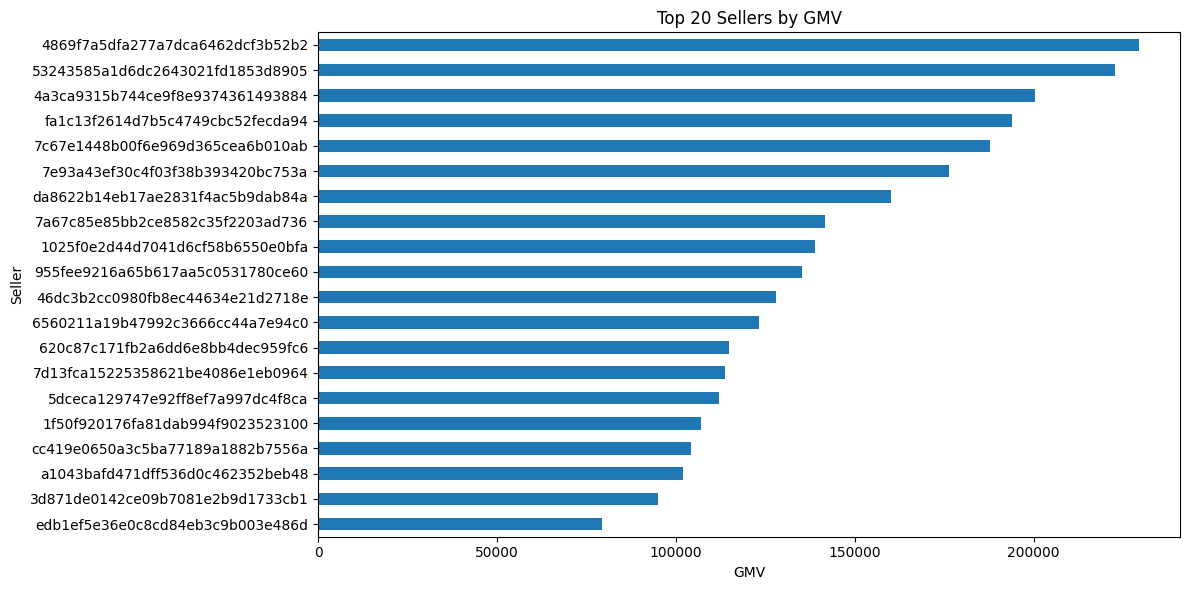

In [23]:
import matplotlib.pyplot as plt

top20 = seller_gmv.head(20)

plt.figure(figsize=(12,6))
top20.sort_values().plot(kind='barh')
plt.title('Top 20 Sellers by GMV')
plt.xlabel('GMV')
plt.ylabel('Seller')
plt.tight_layout()
plt.show()

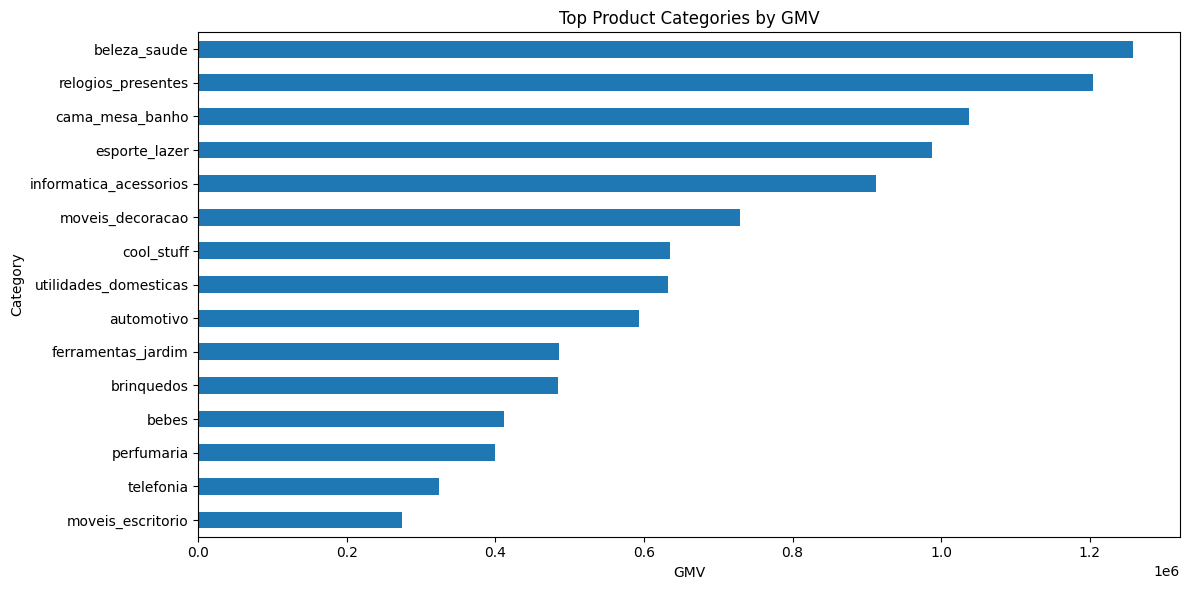

In [24]:
top_categories = category_analysis.head(15)

plt.figure(figsize=(12,6))
top_categories['GMV'].sort_values().plot(kind='barh')
plt.title('Top Product Categories by GMV')
plt.xlabel('GMV')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

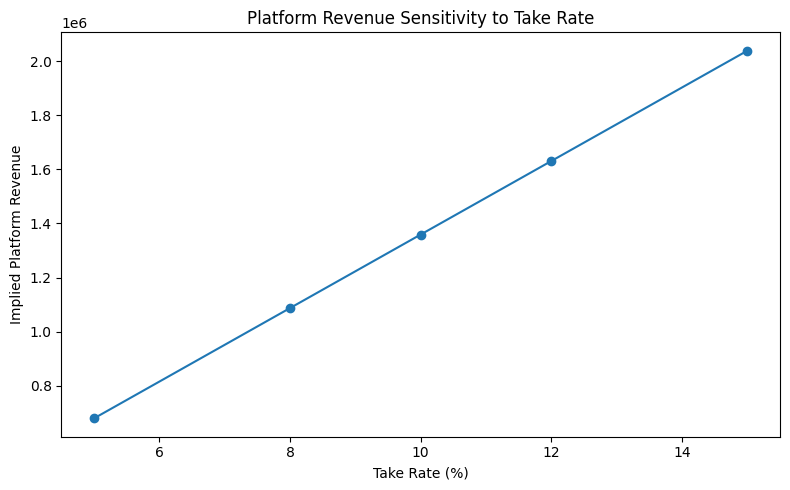

In [25]:
plt.figure(figsize=(8,5))
plt.plot(
    scenario['Take_Rate'] * 100,
    scenario['Implied_Platform_Revenue'],
    marker='o'
)

plt.title('Platform Revenue Sensitivity to Take Rate')
plt.xlabel('Take Rate (%)')
plt.ylabel('Implied Platform Revenue')
plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# 13. SAVE OUTPUTS
# ============================================================

import os

output_path = "/content/drive/MyDrive/marketplace-economics-analysis/outputs"

os.makedirs(output_path, exist_ok=True)

scorecard.to_csv(
    output_path + "/marketplace_scorecard.csv",
    index=False
)

category_analysis.to_csv(
    output_path + "/category_economics.csv"
)

seller_performance.to_csv(
    output_path + "/seller_performance.csv"
)

scenario.to_csv(
    output_path + "/take_rate_scenarios.csv",
    index=False
)

print("Outputs saved successfully.")

Outputs saved successfully.


In [30]:
print("orders columns:")
print(orders.columns.tolist())

print("\nitems columns:")
print(items.columns.tolist())

print("\nDoes delay_days exist?", 'delay_days' in orders.columns)

orders columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_days', 'delay_days']

items columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Does delay_days exist? True


In [31]:
# ============================================================
# SELLER DELIVERY PERFORMANCE — CLEAN VERSION
# ============================================================

seller_data = items[['order_id', 'seller_id']].merge(
    orders[['order_id', 'order_status', 'delay_days']],
    on='order_id',
    how='left'
)

# Keep only completed deliveries
seller_data = seller_data[
    seller_data['order_status'].eq('delivered')
].copy()

# Create late indicator
seller_data['is_late'] = (seller_data['delay_days'] > 0).astype(int)

# Calculate seller-level delivery metrics
seller_delivery = seller_data.groupby('seller_id').agg(
    Delivered_Orders=('order_id', 'nunique'),
    Avg_Delay=('delay_days', 'mean'),
    Late_Rate=('is_late', 'mean')
)

# Convert late rate to percentage
seller_delivery['Late_Rate'] = seller_delivery['Late_Rate'] * 100

# Seller GMV and order count
seller_gmv = items.groupby('seller_id')['price'].sum()
seller_orders = items.groupby('seller_id')['order_id'].nunique()

# Combine everything
seller_performance = pd.DataFrame({
    'GMV': seller_gmv,
    'Orders': seller_orders
}).join(seller_delivery, how='inner')

# AOV
seller_performance['AOV'] = (
    seller_performance['GMV'] /
    seller_performance['Orders']
)

print("Seller performance created successfully!")
print(f"Sellers analyzed: {len(seller_performance):,}")
print()
print(seller_performance.head())

Seller performance created successfully!
Sellers analyzed: 2,970

                                       GMV  Orders  Delivered_Orders  \
seller_id                                                              
0015a82c2db000af6aaaf3ae2ecb0532   2685.00       3                 3   
001cca7ae9ae17fb1caed9dfb1094831  25080.03     200               195   
002100f778ceb8431b7a1020ff7ab48f   1234.50      51                50   
003554e2dce176b5555353e4f3555ac8    120.00       1                 1   
004c9cd9d87a3c30c522c48c4fc07416  19712.71     158               156   

                                  Avg_Delay  Late_Rate         AOV  
seller_id                                                           
0015a82c2db000af6aaaf3ae2ecb0532 -15.593380   0.000000  895.000000  
001cca7ae9ae17fb1caed9dfb1094831 -12.569366   5.555556  125.400150  
002100f778ceb8431b7a1020ff7ab48f  -7.395119  16.666667   24.205882  
003554e2dce176b5555353e4f3555ac8 -26.066794   0.000000  120.000000  
004c9cd9d87a3c3

In [32]:
# ============================================================
# HIGH-VALUE + HIGH-RISK SELLERS
# ============================================================

gmv_threshold = seller_performance['GMV'].quantile(0.75)
late_threshold = seller_performance['Late_Rate'].quantile(0.75)

priority_sellers = seller_performance[
    (seller_performance['GMV'] >= gmv_threshold) &
    (seller_performance['Late_Rate'] >= late_threshold)
].sort_values('GMV', ascending=False)

print("HIGH-VALUE / HIGH-RISK SELLERS")
print("-" * 50)
print(f"GMV threshold: ${gmv_threshold:,.2f}")
print(f"Late-rate threshold: {late_threshold:.2f}%")
print(f"Priority sellers: {len(priority_sellers):,}")
print()

print(
    priority_sellers[
        ['GMV', 'Orders', 'AOV', 'Avg_Delay', 'Late_Rate']
    ].head(15)
)

HIGH-VALUE / HIGH-RISK SELLERS
--------------------------------------------------
GMV threshold: $3,586.02
Late-rate threshold: 10.00%
Priority sellers: 228

                                        GMV  Orders         AOV  Avg_Delay  \
seller_id                                                                    
4869f7a5dfa277a7dca6462dcf3b52b2  229472.63    1132  202.714337 -10.453161   
4a3ca9315b744ce9f8e9374361493884  200472.92    1806  111.003832  -8.954641   
fa1c13f2614d7b5c4749cbc52fecda94  194042.03     585  331.695778  -9.612764   
7d13fca15225358621be4086e1eb0964  113628.97     565  201.113221 -10.292241   
f7ba60f8c3f99e7ee4042fdef03b70c4   68395.00     219  312.305936  -8.449990   
04308b1ee57b6625f47df1d56f00eedf   60130.60      94  639.687234 -10.881929   
522620dcb18a6b31cd7bdf73665113a9   57168.49     174  328.554540 -13.379501   
f5a590cf36251cf1162ea35bef76fe84   53201.78     117  454.716068 -10.347347   
8160255418d5aaa7dbdc9f4c64ebda44   47017.69     385  122.12387

In [33]:
# Final seller opportunity analysis

priority_sellers = seller_performance[
    (seller_performance['GMV'] >= seller_performance['GMV'].quantile(0.75)) &
    (seller_performance['Late_Rate'] >= seller_performance['Late_Rate'].quantile(0.75))
].copy()

print("Priority sellers:", len(priority_sellers))
print()
print(priority_sellers[
    ['GMV', 'Orders', 'AOV', 'Avg_Delay', 'Late_Rate']
].sort_values('GMV', ascending=False).head(15))

Priority sellers: 228

                                        GMV  Orders         AOV  Avg_Delay  \
seller_id                                                                    
4869f7a5dfa277a7dca6462dcf3b52b2  229472.63    1132  202.714337 -10.453161   
4a3ca9315b744ce9f8e9374361493884  200472.92    1806  111.003832  -8.954641   
fa1c13f2614d7b5c4749cbc52fecda94  194042.03     585  331.695778  -9.612764   
7d13fca15225358621be4086e1eb0964  113628.97     565  201.113221 -10.292241   
f7ba60f8c3f99e7ee4042fdef03b70c4   68395.00     219  312.305936  -8.449990   
04308b1ee57b6625f47df1d56f00eedf   60130.60      94  639.687234 -10.881929   
522620dcb18a6b31cd7bdf73665113a9   57168.49     174  328.554540 -13.379501   
f5a590cf36251cf1162ea35bef76fe84   53201.78     117  454.716068 -10.347347   
8160255418d5aaa7dbdc9f4c64ebda44   47017.69     385  122.123870  -6.833375   
77530e9772f57a62c906e1c21538ab82   46610.40     320  145.657500 -10.197883   
4e922959ae960d389249c378d1c939f5   46030.

In [34]:
# ============================================================
# CATEGORY OPPORTUNITY
# ============================================================

category_sales = items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

category_analysis = (
    category_sales
    .groupby('product_category_name')
    .agg(
        GMV=('price', 'sum'),
        Orders=('order_id', 'nunique'),
        Items_Sold=('order_id', 'count'),
        Sellers=('seller_id', 'nunique'),
        Avg_Item_Value=('price', 'mean')
    )
    .sort_values('GMV', ascending=False)
)

category_analysis['GMV_Share_%'] = (
    category_analysis['GMV'] /
    category_analysis['GMV'].sum() * 100
)

category_analysis['Order_Share_%'] = (
    category_analysis['Orders'] /
    category_analysis['Orders'].sum() * 100
)

print("TOP CATEGORIES BY GMV")
print("-" * 60)

print(
    category_analysis[
        ['GMV', 'Orders', 'Sellers', 'Avg_Item_Value', 'GMV_Share_%']
    ].head(20)
)

TOP CATEGORIES BY GMV
------------------------------------------------------------
                               GMV  Orders  Sellers  Avg_Item_Value  \
product_category_name                                                 
beleza_saude            1258681.34    8836      492      130.163531   
relogios_presentes      1205005.68    5624      101      201.135984   
cama_mesa_banho         1036988.68    9417      196       93.296327   
esporte_lazer            988048.97    7720      481      114.344285   
informatica_acessorios   911954.32    6689      287      116.513903   
moveis_decoracao         729762.49    6449      370       87.564494   
cool_stuff               635290.85    3632      267      167.357969   
utilidades_domesticas    632248.66    5884      468       90.788148   
automotivo               592720.11    3897      383      139.957523   
ferramentas_jardim       485256.46    3518      237      111.630196   
brinquedos               483946.60    3886      252      117.5483

In [35]:
# ============================================================
# CATEGORY SUPPLY OPPORTUNITY
# ============================================================

category_analysis['GMV_per_Seller'] = (
    category_analysis['GMV'] /
    category_analysis['Sellers']
)

category_analysis['Orders_per_Seller'] = (
    category_analysis['Orders'] /
    category_analysis['Sellers']
)

# Focus on meaningful categories:
# at least 1,000 orders and $200K+ GMV
opportunity_categories = category_analysis[
    (category_analysis['Orders'] >= 1000) &
    (category_analysis['GMV'] >= 200000)
].copy()

opportunity_categories = opportunity_categories.sort_values(
    'GMV_per_Seller',
    ascending=False
)

print("CATEGORY SUPPLY OPPORTUNITIES")
print("-" * 70)

print(
    opportunity_categories[
        [
            'GMV',
            'Orders',
            'Sellers',
            'GMV_per_Seller',
            'Orders_per_Seller',
            'Avg_Item_Value'
        ]
    ].head(15)
)

CATEGORY SUPPLY OPPORTUNITIES
----------------------------------------------------------------------
                               GMV  Orders  Sellers  GMV_per_Seller  \
product_category_name                                                 
relogios_presentes      1205005.68    5624      101    11930.749307   
moveis_escritorio        273960.70    1273       34     8057.667647   
cama_mesa_banho         1036988.68    9417      196     5290.758571   
informatica_acessorios   911954.32    6689      287     3177.541185   
beleza_saude            1258681.34    8836      492     2558.295407   
cool_stuff               635290.85    3632      267     2379.366479   
perfumaria               399124.87    3162      175     2280.713543   
telefonia                323667.53    4199      149     2172.265302   
esporte_lazer            988048.97    7720      481     2054.155863   
ferramentas_jardim       485256.46    3518      237     2047.495612   
moveis_decoracao         729762.49    6449     

In [36]:
# ============================================================
# CATEGORY SELLER CONCENTRATION
# ============================================================

category_seller = (
    category_sales
    .groupby(['product_category_name', 'seller_id'])['price']
    .sum()
    .reset_index()
)

def top10_seller_share(group):
    return (
        group.sort_values('price', ascending=False)
        .head(10)['price']
        .sum()
        / group['price'].sum()
        * 100
    )

category_concentration = (
    category_seller
    .groupby('product_category_name')
    .apply(top10_seller_share, include_groups=False)
    .rename('Top10_Seller_GMV_Share_%')
)

category_opportunity = (
    opportunity_categories
    .join(category_concentration)
    .sort_values('GMV', ascending=False)
)

print("CATEGORY SELLER CONCENTRATION")
print("-" * 70)

print(
    category_opportunity[
        [
            'GMV',
            'Orders',
            'Sellers',
            'GMV_per_Seller',
            'Orders_per_Seller',
            'Top10_Seller_GMV_Share_%'
        ]
    ].head(15)
)

CATEGORY SELLER CONCENTRATION
----------------------------------------------------------------------
                               GMV  Orders  Sellers  GMV_per_Seller  \
product_category_name                                                 
beleza_saude            1258681.34    8836      492     2558.295407   
relogios_presentes      1205005.68    5624      101    11930.749307   
cama_mesa_banho         1036988.68    9417      196     5290.758571   
esporte_lazer            988048.97    7720      481     2054.155863   
informatica_acessorios   911954.32    6689      287     3177.541185   
moveis_decoracao         729762.49    6449      370     1972.331054   
cool_stuff               635290.85    3632      267     2379.366479   
utilidades_domesticas    632248.66    5884      468     1350.958675   
automotivo               592720.11    3897      383     1547.572089   
ferramentas_jardim       485256.46    3518      237     2047.495612   
brinquedos               483946.60    3886     

In [37]:
# ============================================================
# CATEGORY CONCENTRATION OPPORTUNITY
# ============================================================

category_opportunity['GMV_at_Risk_%'] = (
    category_opportunity['Top10_Seller_GMV_Share_%']
)

category_opportunity['GMV_at_Risk'] = (
    category_opportunity['GMV'] *
    category_opportunity['Top10_Seller_GMV_Share_%'] / 100
)

# Rank by economic exposure
concentration_opportunity = category_opportunity.sort_values(
    'GMV_at_Risk',
    ascending=False
)

print("CATEGORY CONCENTRATION OPPORTUNITY")
print("-" * 75)

print(
    concentration_opportunity[
        [
            'GMV',
            'Sellers',
            'Top10_Seller_GMV_Share_%',
            'GMV_at_Risk',
            'Orders_per_Seller'
        ]
    ].head(15)
)

CATEGORY CONCENTRATION OPPORTUNITY
---------------------------------------------------------------------------
                               GMV  Sellers  Top10_Seller_GMV_Share_%  \
product_category_name                                                   
relogios_presentes      1205005.68      101                 78.850875   
cama_mesa_banho         1036988.68      196                 55.264796   
beleza_saude            1258681.34      492                 42.615438   
informatica_acessorios   911954.32      287                 38.181974   
cool_stuff               635290.85      267                 54.469398   
moveis_decoracao         729762.49      370                 46.812121   
esporte_lazer            988048.97      481                 30.827034   
perfumaria               399124.87      175                 70.200030   
ferramentas_jardim       485256.46      237                 57.022513   
moveis_escritorio        273960.70       34                 94.380256   
automotivo   

In [38]:
# ============================================================
# FINAL MARKETPLACE EXPOSURE
# ============================================================

total_concentration_exposure = (
    concentration_opportunity['GMV_at_Risk'].sum()
)

print("FINAL MARKETPLACE EXPOSURE")
print("-" * 60)
print(f"Total marketplace GMV: ${gmv:,.2f}")
print(f"GMV exposed to top-10 category concentration: "
      f"${total_concentration_exposure:,.2f}")
print(f"Share of marketplace GMV: "
      f"{total_concentration_exposure / gmv * 100:.2f}%")

FINAL MARKETPLACE EXPOSURE
------------------------------------------------------------
Total marketplace GMV: $13,591,643.70
GMV exposed to top-10 category concentration: $5,473,333.28
Share of marketplace GMV: 40.27%
